# Logistic Regression from Scratch - Interview Preparation Guide

## 📚 Table of Contents
1. [Goal and Objective](#goal)
2. [Loss Function](#loss-function)
3. [Algorithm Overview](#algorithm)
4. [Key Concepts for Interviews](#key-concepts)
5. [Implementation](#implementation)

---

## 🎯 Goal and Objective {#goal}

**Logistic Regression is a supervised learning algorithm for binary classification.**

### Primary Goal:
- **Classify** data points into one of two classes (0 or 1)
- **Model** the probability that a data point belongs to class 1: P(y=1|x)
- **Learn** a decision boundary that separates the two classes

### Key Characteristics:
- **Supervised**: Requires labeled training data
- **Probabilistic**: Outputs probabilities, not just binary predictions
- **Linear**: Decision boundary is linear (can be extended with polynomial features)
- **Discriminative**: Models P(y|x) directly, not P(x|y)

### Mathematical Model:

The logistic regression model predicts:

$$P(y=1|x) = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$$

Where:
- $w$ = weight vector (learned parameters)
- $b$ = bias term (learned parameter)
- $\sigma(z)$ = sigmoid function
- $x$ = input features

### When to Use Logistic Regression:

✅ Binary classification problems  
✅ Need probability estimates (not just predictions)  
✅ Features are linearly separable (or can be made so)  
✅ Interpretable model (can see feature importance)  
✅ Fast training and prediction  
✅ Works well with small to medium datasets  

❌ Non-linear decision boundaries (without feature engineering)  
❌ Multi-class problems (need extensions like one-vs-rest)  
❌ Very large datasets (consider neural networks)  
❌ Features are highly correlated (multicollinearity issues)

## 📉 Loss Function: Binary Cross-Entropy {#loss-function}

### Mathematical Formulation

The **objective function** (what we minimize) is **Binary Cross-Entropy Loss**:

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1-y^{(i)}) \log(1-\hat{y}^{(i)}) \right]$$

Where:
- $m$ = number of training samples
- $y^{(i)}$ = true label for sample $i$ (0 or 1)
- $\hat{y}^{(i)} = \sigma(w^T x^{(i)} + b)$ = predicted probability for sample $i$
- $\log$ = natural logarithm

### Breaking Down the Loss Function:

1. **For each sample $i$**: 
   - If $y^{(i)} = 1$: loss = $-\log(\hat{y}^{(i)})$ (penalizes low probability for class 1)
   - If $y^{(i)} = 0$: loss = $-\log(1-\hat{y}^{(i)})$ (penalizes high probability for class 1)

2. **Average across all samples**: Sum and divide by $m$

3. **Minimize**: The algorithm tries to find $w$ and $b$ that minimize this loss

### Why This Loss Function?

- **Convex**: Guarantees a global minimum (unlike neural networks)
- **Probabilistic interpretation**: Derived from maximum likelihood estimation
- **Well-behaved gradients**: Smooth and differentiable everywhere
- **Penalizes confident wrong predictions**: Heavily penalizes predictions far from true labels

### Gradient Descent Update Rules:

$$\frac{\partial J}{\partial w} = \frac{1}{m} X^T (\hat{y} - y)$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

**Update equations:**
$$w := w - \alpha \frac{\partial J}{\partial w}$$
$$b := b - \alpha \frac{\partial J}{\partial b}$$

Where $\alpha$ is the learning rate.

### Interview Question: "Why not use Mean Squared Error (MSE)?"

**Answer**: 
- MSE assumes Gaussian noise, but binary classification has Bernoulli distribution
- MSE loss is non-convex for logistic regression (multiple local minima)
- MSE gradients vanish when predictions are confident (sigmoid saturates)
- Cross-entropy provides better gradients for learning


## 🔄 Algorithm Overview {#algorithm}

### Logistic Regression Training Steps:

#### **Step 1: Initialize Parameters**
- Initialize weights $w$ to small random values (or zeros)
- Initialize bias $b$ to 0 (or small random value)
- **Why small values?** Prevents sigmoid from saturating initially

#### **Step 2: Forward Propagation**
- Compute linear combination: $z = w^T x + b$
- Apply sigmoid: $\hat{y} = \sigma(z) = \frac{1}{1+e^{-z}}$
- This gives probability $P(y=1|x)$

#### **Step 3: Compute Loss**
- Calculate binary cross-entropy loss
- Measures how far predictions are from true labels

#### **Step 4: Backward Propagation (Gradient Computation)**
- Compute gradients: $\frac{\partial J}{\partial w}$ and $\frac{\partial J}{\partial b}$
- These tell us which direction to update parameters

#### **Step 5: Update Parameters**
- Update using gradient descent:
  - $w := w - \alpha \frac{\partial J}{\partial w}$
  - $b := b - \alpha \frac{\partial J}{\partial b}$
- $\alpha$ = learning rate (controls step size)

#### **Step 6: Repeat**
- Repeat steps 2-5 until convergence or max iterations
- Convergence: loss stops decreasing significantly

### The Sigmoid Function:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Properties:**
- Output range: (0, 1) - perfect for probabilities
- Smooth and differentiable everywhere
- S-shaped curve (S-curve)
- $\sigma(0) = 0.5$ (decision boundary)
- Derivative: $\sigma'(z) = \sigma(z)(1-\sigma(z))$ (used in backprop)

### Why Sigmoid?

- **Bounded**: Outputs are always between 0 and 1 (probabilities)
- **Monotonic**: Larger $z$ → larger probability
- **Smooth**: Differentiable everywhere (needed for gradient descent)
- **Interpretable**: Can think of $z$ as "log-odds" (logit)

### Decision Boundary:

The decision boundary is where $P(y=1|x) = 0.5$, which occurs when:
$$w^T x + b = 0$$

This is a **linear decision boundary** in feature space.


## 💡 Key Concepts for Interviews {#key-concepts}

### 1. **Time Complexity**
- **Training**: O(n × d × i) where n=samples, d=features, i=iterations
- **Prediction**: O(d) per sample (just matrix multiplication + sigmoid)
- Typically converges in 100-1000 iterations for well-scaled data

### 2. **Space Complexity**
- O(d) to store weights and bias
- O(n × d) to store training data
- **Total**: O(n × d) (dominated by data storage)

### 3. **Convergence Guarantees**
- ✅ **Convex optimization**: Binary cross-entropy is convex → global minimum guaranteed
- ✅ **Always converges** (with proper learning rate)
- ⚠️ **Learning rate matters**: Too high → divergence, too low → slow convergence

### 4. **Regularization**

**L2 Regularization (Ridge):**
$$J_{reg} = J + \frac{\lambda}{2m} ||w||^2$$

**L1 Regularization (Lasso):**
$$J_{reg} = J + \frac{\lambda}{m} |w|$$

- Prevents overfitting by penalizing large weights
- $\lambda$ = regularization strength (hyperparameter)
- L1 can drive weights to exactly 0 (feature selection)

### 5. **Common Interview Questions**

**Q: What's the difference between Logistic Regression and Linear Regression?**  
A: 
- Linear Regression: Predicts continuous values, uses MSE loss
- Logistic Regression: Predicts probabilities (0-1), uses cross-entropy loss, applies sigmoid

**Q: Why is it called "Logistic Regression" if it's for classification?**  
A: 
- "Logistic" refers to the logistic (sigmoid) function
- "Regression" is historical - it models the log-odds (logit) as a linear function
- Log-odds: $\log(\frac{p}{1-p}) = w^T x + b$

**Q: How do you handle multi-class classification?**  
A: 
- **One-vs-Rest (OvR)**: Train k binary classifiers (one per class)
- **One-vs-One (OvO)**: Train k(k-1)/2 binary classifiers (one per pair)
- **Softmax Regression**: Direct extension using softmax instead of sigmoid

**Q: What happens if features are not scaled?**  
A: 
- Gradient descent converges slowly (features on different scales)
- May not converge at all if learning rate is too high for large features
- **Always scale features** (StandardScaler, MinMaxScaler)

**Q: How do you interpret the weights?**  
A: 
- Larger $|w_i|$ = feature $i$ is more important
- Positive $w_i$ = feature $i$ increases probability of class 1
- Negative $w_i$ = feature $i$ decreases probability of class 1
- Can compute odds ratio: $e^{w_i}$ = how odds change per unit increase in feature $i$

**Q: What are the assumptions of Logistic Regression?**  
A: 
- Binary outcome (or can be extended to multi-class)
- Features are linearly related to log-odds
- Observations are independent
- No multicollinearity (highly correlated features)
- Large sample size (rule of thumb: 10-20 samples per feature)

**Q: How do you handle imbalanced classes?**  
A: 
- **Class weights**: Penalize misclassifying minority class more
- **Resampling**: Oversample minority class or undersample majority class
- **Threshold tuning**: Adjust decision threshold (default 0.5)
- **Different metrics**: Use precision, recall, F1, or AUC instead of accuracy

**Q: Can Logistic Regression handle non-linear boundaries?**  
A: 
- **Directly**: No, it's linear
- **With feature engineering**: Yes! Add polynomial features, interactions
- **Kernel trick**: Not directly, but can use kernel methods
- **Alternative**: Use neural networks for complex non-linear boundaries


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Optional
import warnings
warnings.filterwarnings('ignore')

class LogisticRegression:
    """
    Logistic Regression Classifier - Complete Implementation from Scratch
    
    This is a complete implementation of Logistic Regression with detailed comments
    for interview preparation.
    
    Features:
    - Binary classification using sigmoid activation
    - Binary cross-entropy loss function
    - Gradient descent optimization
    - Probability predictions
    - Binary predictions with configurable threshold
    - Training history tracking
    """
    
    def __init__(self, learning_rate: float = 0.01, max_iterations: int = 1000, 
                 convergence_threshold: float = 1e-6, random_seed: Optional[int] = None):
        """
        Initialize Logistic Regression model
        
        Args:
            learning_rate: Step size for gradient descent (α)
                - Too high → may diverge
                - Too low → slow convergence
                - Typical range: 0.001 to 0.1
            max_iterations: Maximum number of training iterations
            convergence_threshold: Stop training if loss change < threshold
            random_seed: Random seed for reproducibility
        """
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.convergence_threshold = convergence_threshold
        self.w = None  # Weights (n_features, 1)
        self.b = None  # Bias (scalar)
        self.loss_history = []  # Track loss during training
        
        if random_seed is not None:
            np.random.seed(random_seed)
    
    def _sigmoid(self, z: np.ndarray) -> np.ndarray:
        """
        STEP 1: Sigmoid Activation Function
        
        The sigmoid function maps any real number to the range (0, 1).
        This is perfect for binary classification because it outputs probabilities.
        
        Mathematical formula:
            σ(z) = 1 / (1 + e^(-z))
        
        Interview Notes:
        - Why sigmoid? Bounded output (0,1), smooth, differentiable, interpretable
        - Properties: σ(0) = 0.5, σ(∞) = 1, σ(-∞) = 0
        - Derivative: σ'(z) = σ(z)(1-σ(z)) - used in backpropagation
        - Alternative: tanh (range -1 to 1) or ReLU (for neural networks)
        
        Args:
            z: Input values (can be scalar, vector, or matrix)
            
        Returns:
            Sigmoid of z, same shape as input, values in (0, 1)
        """
        # Clip z to prevent overflow in exp(-z) when z is very negative
        # This is a numerical stability trick
        z_clipped = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z_clipped))
    
    def _initialize_parameters(self, n_features: int):
        """
        STEP 2: Parameter Initialization
        
        Initialize weights and bias for logistic regression.
        
        Interview Notes:
        - Why small random values? Prevents sigmoid from saturating initially
        - If weights are too large → sigmoid outputs near 0 or 1 → gradients vanish
        - If weights are zero → all samples get same prediction → symmetry breaking needed
        - Common strategies: small random (this), Xavier/Glorot, He initialization
        
        Args:
            n_features: Number of input features
            
        Returns:
            w: Weight vector of shape (n_features, 1) - initialized to small random values
            b: Bias scalar - initialized to 0.0
        """
        # Initialize weights: small random values from standard normal distribution
        # Multiply by 0.01 to keep values small (prevents sigmoid saturation)
        # Shape: (n_features, 1) to allow matrix multiplication with X
        w = np.random.randn(n_features, 1) * 0.01
        
        # Initialize bias to 0 (common practice)
        # Could also use small random value, but 0 is fine for bias
        b = 0.0
        
        return w, b
    
    def _forward_propagation(self, X: np.ndarray) -> np.ndarray:
        """
        STEP 3: Forward Propagation - Compute Probabilities
        
        This is the "forward pass" of logistic regression:
        1. Compute linear combination: z = w^T x + b
        2. Apply sigmoid: P(y=1|x) = σ(z)
        
        Mathematical operation:
            z = X @ w + b  (matrix multiplication + broadcasting)
            ŷ = σ(z) = 1 / (1 + e^(-z))
        
        Interview Notes:
        - This is the core prediction function
        - Output is probability, not binary prediction (use threshold for binary)
        - Can interpret as: "probability that sample belongs to class 1"
        - Decision boundary: where P(y=1|x) = 0.5, i.e., z = 0
        
        Args:
            X: Input features, shape (n_samples, n_features)
            
        Returns:
            Probabilities P(y=1|x) for each sample, shape (n_samples, 1)
        """
        # Step 1: Compute linear combination z = w^T x + b
        # X @ w: matrix multiplication (n_samples, n_features) @ (n_features, 1) = (n_samples, 1)
        # + b: broadcasting adds bias to each sample
        # z represents the "logit" (log-odds before sigmoid)
        z = X @ self.w + self.b  # shape: (n_samples, 1)
        
        # Step 2: Apply sigmoid to get probabilities
        # This maps z from (-∞, +∞) to (0, 1)
        return self._sigmoid(z)
    
    def _compute_loss_and_gradients(self, X: np.ndarray, y: np.ndarray) -> Tuple[float, np.ndarray, float]:
        """
        STEP 4: Compute Loss and Gradients (Backward Propagation)
        
        This function computes:
        1. Binary Cross-Entropy Loss (the objective function we minimize)
        2. Gradients with respect to weights and bias (for gradient descent)
        
        Loss Function (Binary Cross-Entropy):
            J = -(1/m) Σ [y*log(ŷ) + (1-y)*log(1-ŷ)]
        
        Where:
            - m = number of samples
            - y = true label (0 or 1)
            - ŷ = predicted probability P(y=1|x)
        
        Gradient Derivation (using chain rule):
            ∂J/∂w = (1/m) * X^T * (ŷ - y)
            ∂J/∂b = (1/m) * Σ(ŷ - y)
        
        Interview Notes:
        - Why cross-entropy? Convex, well-behaved gradients, probabilistic interpretation
        - Why not MSE? MSE is non-convex for sigmoid, gradients vanish when confident
        - Clipping prevents log(0) which would give -∞
        - Gradients are simple: just the difference between prediction and true label!
        
        Args:
            X: Input features, shape (n_samples, n_features)
            y: True labels (0 or 1), shape (n_samples, 1)
            
        Returns:
            loss: Scalar, average binary cross-entropy loss
            dw: Gradient of loss w.r.t w, shape (n_features, 1)
            db: Gradient of loss w.r.t b (scalar)
        """
        m = X.shape[0]  # Number of samples (for averaging)
        
        # Forward pass: compute predicted probabilities
        y_pred = self._forward_propagation(X)
        
        # CRITICAL: Clip predictions to avoid log(0) = -∞
        # If y_pred = 0 or 1 exactly, log(0) or log(1-1) would be undefined
        # Clip to (ε, 1-ε) where ε is very small (e.g., 1e-15)
        eps = 1e-15
        y_pred_clipped = np.clip(y_pred, eps, 1 - eps)
        
        # ========================================================================
        # BINARY CROSS-ENTROPY LOSS COMPUTATION
        # ========================================================================
        # Formula: J = -(1/m) Σ [y*log(ŷ) + (1-y)*log(1-ŷ)]
        #
        # Breaking it down:
        # - If y=1: loss contribution = -log(ŷ) (penalizes low probability for class 1)
        # - If y=0: loss contribution = -log(1-ŷ) (penalizes high probability for class 1)
        # - Sum over all samples, then average (divide by m)
        # - Negative sign because we want to maximize log-likelihood (minimize negative)
        #
        # Interview Note: This is derived from maximum likelihood estimation (MLE)
        # for Bernoulli distribution (binary outcomes)
        loss = - (1.0 / m) * np.sum(y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped))
        
        # ========================================================================
        # GRADIENT COMPUTATION (Backward Propagation)
        # ========================================================================
        # The gradient tells us the direction of steepest increase in loss.
        # We move in the opposite direction (gradient descent) to minimize loss.
        #
        # Mathematical derivation (chain rule):
        # 1. ∂J/∂ŷ = (ŷ - y) / (ŷ(1-ŷ))  (from cross-entropy loss)
        # 2. ∂ŷ/∂z = ŷ(1-ŷ)  (sigmoid derivative)
        # 3. ∂z/∂w = X, ∂z/∂b = 1
        # 4. Chain rule: ∂J/∂w = ∂J/∂ŷ * ∂ŷ/∂z * ∂z/∂w = (ŷ - y) * X
        # 5. Average over samples: ∂J/∂w = (1/m) * X^T * (ŷ - y)
        #
        # The key insight: gradient is simply the difference between prediction and truth!
        
        # Gradient w.r.t. z (before sigmoid): dz = ŷ - y
        # This is the "error signal" - how far off our prediction is
        dz = y_pred - y  # shape: (n_samples, 1)
        
        # Gradient w.r.t. weights: dw = (1/m) * X^T * dz
        # X.T: transpose to get (n_features, n_samples)
        # X.T @ dz: matrix multiplication gives (n_features, 1)
        # This averages the gradient contribution from all samples
        dw = (1.0 / m) * (X.T @ dz)  # shape: (n_features, 1)
        
        # Gradient w.r.t. bias: db = (1/m) * Σ(dz)
        # Bias affects all samples equally, so we just average dz
        db = (1.0 / m) * np.sum(dz)  # scalar
        
        return loss, dw, db
    
    def fit(self, X: np.ndarray, y: np.ndarray, verbose: bool = True) -> 'LogisticRegression':
        """
        STEP 5: Training Loop - Gradient Descent Optimization
        
        This is the main training function that implements gradient descent to minimize
        the binary cross-entropy loss.
        
        Algorithm (Gradient Descent):
        1. Initialize parameters (w, b)
        2. For each iteration:
           a. Forward pass: compute predictions and loss
           b. Backward pass: compute gradients
           c. Update parameters: w = w - α*∂J/∂w, b = b - α*∂J/∂b
           d. Check for convergence
        3. Return trained parameters
        
        Interview Notes:
        - Gradient descent: move in direction opposite to gradient (steepest descent)
        - Learning rate (α): controls step size
          * Too high → overshoot, may diverge
          * Too low → slow convergence
          * Rule of thumb: start with 0.01, adjust based on loss curve
        - Convergence: stop when loss change < threshold (or loss stops decreasing)
        - Binary cross-entropy is CONVEX → guaranteed global minimum (unlike neural nets!)
        - Can use batch, mini-batch, or stochastic gradient descent variants
        
        Args:
            X: Training features, shape (n_samples, n_features)
            y: Training labels, shape (n_samples, 1) or (n_samples,)
            verbose: Print progress every 100 iterations
            
        Returns:
            self (for method chaining)
        """
        # Ensure y is column vector
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        
        # Initialize parameters (weights and bias)
        n_features = X.shape[1]
        self.w, self.b = self._initialize_parameters(n_features)
        
        # Track loss history for visualization and debugging
        self.loss_history = []
        prev_loss = float('inf')  # Initialize to infinity for first iteration
        
        # ========================================================================
        # GRADIENT DESCENT ITERATION LOOP
        # ========================================================================
        for i in range(self.max_iterations):
            # ====================================================================
            # FORWARD PASS: Compute predictions and loss
            # ====================================================================
            # This computes:
            # 1. y_pred = sigmoid(X @ w + b)  (probabilities)
            # 2. loss = binary_cross_entropy(y, y_pred)
            # 3. gradients: dw, db
            loss, dw, db = self._compute_loss_and_gradients(X, y)
            self.loss_history.append(loss)  # Store for learning curve
            
            # ====================================================================
            # PARAMETER UPDATE: Gradient Descent Step
            # ====================================================================
            # Update rule: θ_new = θ_old - α * ∇J(θ_old)
            # We move in the OPPOSITE direction of the gradient (gradient descent)
            # because gradient points in direction of steepest INCREASE
            
            # Update weights: w = w - α * ∂J/∂w
            # learning_rate controls how big a step we take
            self.w = self.w - self.learning_rate * dw
            
            # Update bias: b = b - α * ∂J/∂b
            self.b = self.b - self.learning_rate * db
            
            # ====================================================================
            # CONVERGENCE CHECK
            # ====================================================================
            # Check if loss has stopped decreasing significantly
            # If loss change is very small, we've converged (found minimum)
            loss_change = abs(prev_loss - loss)
            if loss_change < self.convergence_threshold:
                if verbose:
                    print(f"Converged at iteration {i+1}: loss = {loss:.6f}, change = {loss_change:.2e}")
                break  # Early stopping: we've found the minimum
            
            # ====================================================================
            # WARNING: Loss Increased
            # ====================================================================
            # If loss increases, learning rate might be too high
            # This can happen if we overshoot the minimum
            # In practice, might want to reduce learning rate or use adaptive methods
            if loss > prev_loss and verbose and i > 0:
                print(f"Warning: Loss increased at iteration {i+1}. Consider reducing learning rate.")
            
            prev_loss = loss  # Store for next iteration's convergence check
            
            # ====================================================================
            # PROGRESS REPORTING
            # ====================================================================
            # Print progress periodically to monitor training
            if verbose and (i + 1) % 100 == 0:
                print(f"Iteration {i+1}: loss = {loss:.6f}, change = {loss_change:.2e}")
        
        # ========================================================================
        # FINAL STATUS
        # ========================================================================
        # If we reached max iterations without converging, report it
        if i == self.max_iterations - 1 and verbose:
            print(f"Reached max iterations ({self.max_iterations}). Final loss: {loss:.6f}")
        
        return self
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        Predict probability that each sample belongs to class 1
        
        For Logistic Regression, this is simply the forward propagation step.
        We compute P(y=1|x) = σ(w^T x + b).
        
        Interview Note: This is the core output of logistic regression.
        Binary predictions are derived from probabilities using a threshold.
        
        Args:
            X: Input features, shape (n_samples, n_features)
            
        Returns:
            Probabilities P(y=1|x), shape (n_samples, 1)
        """
        if self.w is None:
            raise ValueError("Model must be fitted before prediction")
        
        return self._forward_propagation(X)
    
    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """
        Predict binary class labels for input features
        
        Converts probabilities to binary predictions using a threshold.
        Default threshold is 0.5, but can be adjusted for precision/recall trade-off.
        
        Interview Note: Threshold tuning is important for imbalanced datasets.
        Lower threshold → more positive predictions (higher recall, lower precision)
        Higher threshold → fewer positive predictions (lower recall, higher precision)
        
        Args:
            X: Input features, shape (n_samples, n_features)
            threshold: Probability threshold for classification (default 0.5)
            
        Returns:
            Binary predictions (0 or 1), shape (n_samples, 1)
        """
        probabilities = self.predict_proba(X)
        y_pred = (probabilities >= threshold).astype(int)
        return y_pred


In [50]:
# ============================================================================
# EXAMPLE: Logistic Regression Demonstration
# ============================================================================
# This example demonstrates the complete Logistic Regression workflow:
# 1. Generate synthetic binary classification data
# 2. Preprocess data (train/test split, feature scaling)
# 3. Train Logistic Regression model
# 4. Evaluate model performance
# 5. Visualize results
# ============================================================================

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# STEP 1: Generate Synthetic Binary Classification Dataset
# ============================================================================
# We'll use sklearn's make_classification for better control over dataset
# characteristics. This provides more flexibility and is a standard approach in ML.

print("=" * 70)
print("STEP 1: Data Generation")
print("=" * 70)

# Generate a 2D binary classification dataset
# Parameters:
#   n_samples: total number of samples
#   n_features: number of features (2 for 2D visualization)
#   n_redundant: redundant features (0 = no redundant features)
#   n_informative: informative features (2 = both features are informative)
#   n_clusters_per_class: number of clusters per class (1 = single cluster)
#   class_sep: separation between classes (higher = easier to separate)
#   random_state: for reproducibility

X, y = make_classification(
    n_samples=400,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,  # Controls how well-separated the classes are
    random_state=42,
    n_classes=2
)

# Reshape y to column vector for consistency
y = y.reshape(-1, 1)

print(f"Dataset Statistics:")
print(f"  Total samples: {len(X)}")
print(f"  Class 0 samples: {np.sum(y == 0)}")
print(f"  Class 1 samples: {np.sum(y == 1)}")
print(f"  Dataset shape: X={X.shape}, y={y.shape}")
print()

# ============================================================================
# STEP 2: Data Preprocessing
# ============================================================================
# Important preprocessing steps:
# 1. Train/test split: Separate data for training and evaluation
# 2. Feature scaling: Critical for gradient descent convergence

print("=" * 70)
print("STEP 2: Data Preprocessing")
print("=" * 70)

# Train/test split using sklearn
# Parameters:
#   test_size: proportion of dataset to include in test split (0.2 = 20%)
#   random_state: for reproducibility
#   shuffle: whether to shuffle data before splitting (default True)
#   stratify: ensures balanced class distribution in train/test (recommended)

X_train, X_test, y_train, y_test = train_test_split(
    X, y.flatten(),  # sklearn expects y to be 1D for stratify
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y.flatten()  # Ensures both sets have similar class distribution
)

# Reshape y back to column vectors for our implementation
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print(f"Train/Test Split:")
print(f"  Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Class distribution in train: Class 0={np.sum(y_train==0)}, Class 1={np.sum(y_train==1)}")
print(f"  Class distribution in test:  Class 0={np.sum(y_test==0)}, Class 1={np.sum(y_test==1)}")

# Feature scaling using StandardScaler
# StandardScaler: (x - mean) / std
# Important: Fit on training data only, then transform both train and test
# This prevents data leakage (using test set statistics to scale training data)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use training statistics, don't fit again!

print(f"\nFeature Scaling (StandardScaler):")
print(f"  Training set mean: {scaler.mean_}")
print(f"  Training set std:  {scaler.scale_}")
print(f"  Scaled training set mean: {X_train_scaled.mean(axis=0)}")
print(f"  Scaled training set std:  {X_train_scaled.std(axis=0)}")
print()

# ============================================================================
# STEP 3: Train Logistic Regression Model
# ============================================================================

print("=" * 70)
print("STEP 3: Model Training")
print("=" * 70)

# Create and train Logistic Regression model
model = LogisticRegression(
    learning_rate=0.1,        # Learning rate (α)
    max_iterations=5000,      # Maximum iterations
    convergence_threshold=1e-6,  # Convergence threshold
    random_seed=42
)

# Train the model
model.fit(X_train_scaled, y_train, verbose=True)

print(f"\nTraining completed!")
print(f"  Final weights: w = {model.w.flatten()}")
print(f"  Final bias: b = {model.b:.6f}")
print(f"  Final training loss: {model.loss_history[-1]:.6f}")
print(f"  Total iterations: {len(model.loss_history)}")
print()


STEP 1: Data Generation
Dataset Statistics:
  Total samples: 400
  Class 0 samples: 200
  Class 1 samples: 200
  Dataset shape: X=(400, 2), y=(400, 1)

STEP 2: Data Preprocessing
Train/Test Split:
  Training set: 320 samples (80.0%)
  Test set:     80 samples (20.0%)
  Class distribution in train: Class 0=160, Class 1=160
  Class distribution in test:  Class 0=40, Class 1=40

Feature Scaling (StandardScaler):
  Training set mean: [1.48549429 0.01837985]
  Training set std:  [0.66539023 1.78098622]
  Scaled training set mean: [ 2.52575738e-16 -1.73472348e-19]
  Scaled training set std:  [1. 1.]

STEP 3: Model Training
Iteration 100: loss = 0.239349, change = 1.03e-03
Iteration 200: loss = 0.181185, change = 3.36e-04
Iteration 300: loss = 0.157464, change = 1.70e-04
Iteration 400: loss = 0.144245, change = 1.04e-04
Iteration 500: loss = 0.135709, change = 7.06e-05
Iteration 600: loss = 0.129700, change = 5.14e-05
Iteration 700: loss = 0.125224, change = 3.91e-05
Iteration 800: loss = 0.1

In [51]:
# ============================================================================
# STEP 4: Model Evaluation
# ============================================================================

print("=" * 70)
print("STEP 4: Model Evaluation")
print("=" * 70)

# Make predictions on training and test sets
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_train_proba = model.predict_proba(X_train_scaled)
y_test_proba = model.predict_proba(X_test_scaled)

# Compute accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Compute confusion matrices
train_cm = confusion_matrix(y_train, y_train_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Print classification reports
print("\nTRAINING SET:")
print(f"  Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Confusion Matrix:")
print(f"    {train_cm}")
print(f"\n  Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=['Class 0', 'Class 1']))

print("\nTEST SET:")
print(f"  Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Confusion Matrix:")
print(f"    {test_cm}")
print(f"\n  Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Class 0', 'Class 1']))

# Compute ROC and PR curves
fpr_train, tpr_train, _ = roc_curve(y_train.flatten(), y_train_proba.flatten())
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, _ = roc_curve(y_test.flatten(), y_test_proba.flatten())
roc_auc_test = auc(fpr_test, tpr_test)

precision_train, recall_train, _ = precision_recall_curve(y_train.flatten(), y_train_proba.flatten())
pr_auc_train = average_precision_score(y_train.flatten(), y_train_proba.flatten())

precision_test, recall_test, _ = precision_recall_curve(y_test.flatten(), y_test_proba.flatten())
pr_auc_test = average_precision_score(y_test.flatten(), y_test_proba.flatten())

print(f"\nAUC Scores:")
print(f"  Training ROC AUC: {roc_auc_train:.4f}")
print(f"  Test ROC AUC:     {roc_auc_test:.4f}")
print(f"  Training PR AUC:  {pr_auc_train:.4f}")
print(f"  Test PR AUC:      {pr_auc_test:.4f}")
print()


STEP 4: Model Evaluation

TRAINING SET:
  Accuracy: 0.9594 (95.94%)
  Confusion Matrix:
    [[152   8]
 [  5 155]]

  Classification Report:
              precision    recall  f1-score   support

     Class 0       0.97      0.95      0.96       160
     Class 1       0.95      0.97      0.96       160

    accuracy                           0.96       320
   macro avg       0.96      0.96      0.96       320
weighted avg       0.96      0.96      0.96       320


TEST SET:
  Accuracy: 0.9125 (91.25%)
  Confusion Matrix:
    [[35  5]
 [ 2 38]]

  Classification Report:
              precision    recall  f1-score   support

     Class 0       0.95      0.88      0.91        40
     Class 1       0.88      0.95      0.92        40

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80


AUC Scores:
  Training ROC AUC: 0.9947
  Test ROC AUC:     0.9781
  Training PR AUC:  0.9948
  T

STEP 5: Visualizations


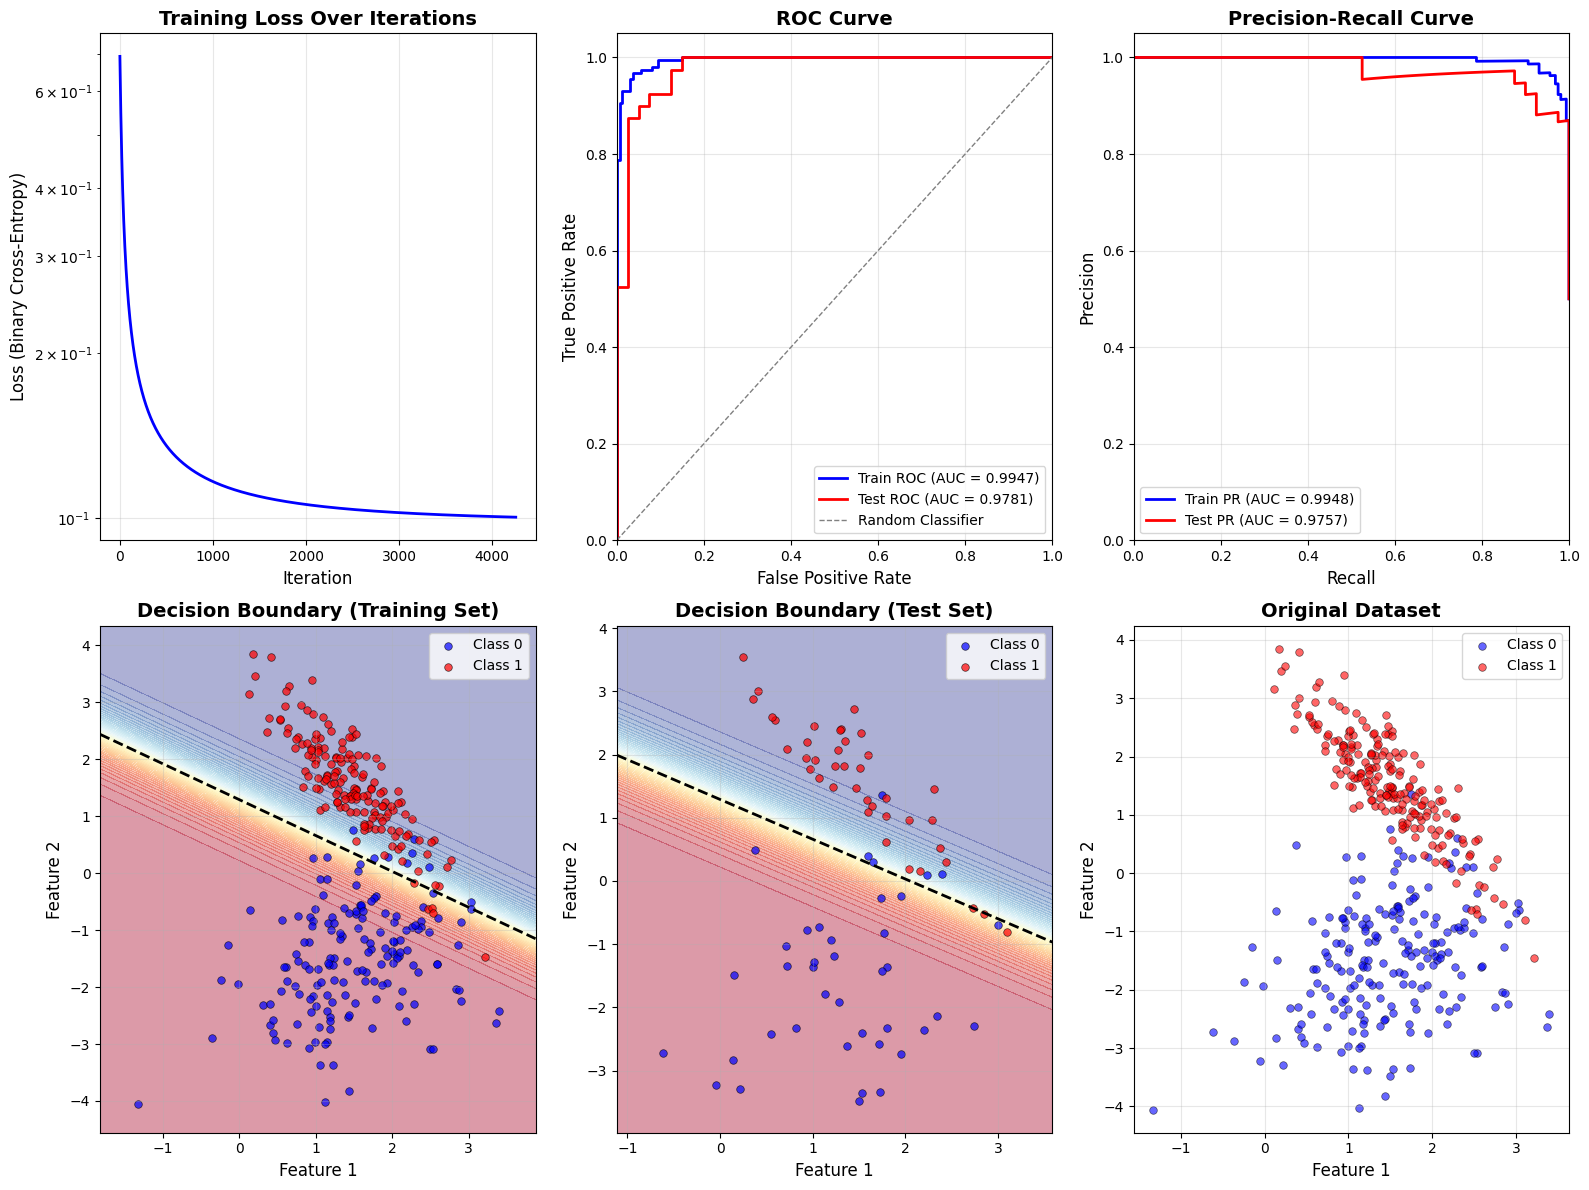

Visualizations completed!



In [52]:
# ============================================================================
# STEP 5: Visualizations
# ============================================================================

print("=" * 70)
print("STEP 5: Visualizations")
print("=" * 70)

# Create figure with subplots
fig = plt.figure(figsize=(16, 12))

# ============================================================================
# Plot 1: Learning Curve (Loss over iterations)
# ============================================================================
plt.subplot(2, 3, 1)
plt.plot(model.loss_history, linewidth=2, color='blue')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss (Binary Cross-Entropy)', fontsize=12)
plt.title('Training Loss Over Iterations', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Log scale to better see convergence

# ============================================================================
# Plot 2: ROC Curve
# ============================================================================
plt.subplot(2, 3, 2)
plt.plot(fpr_train, tpr_train, color='blue', lw=2, 
         label=f'Train ROC (AUC = {roc_auc_train:.4f})')
plt.plot(fpr_test, tpr_test, color='red', lw=2, 
         label=f'Test ROC (AUC = {roc_auc_test:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)

# ============================================================================
# Plot 3: Precision-Recall Curve
# ============================================================================
plt.subplot(2, 3, 3)
plt.plot(recall_train, precision_train, color='blue', lw=2,
         label=f'Train PR (AUC = {pr_auc_train:.4f})')
plt.plot(recall_test, precision_test, color='red', lw=2,
         label=f'Test PR (AUC = {pr_auc_test:.4f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, alpha=0.3)

# ============================================================================
# Plot 4: Decision Boundary on Training Set
# ============================================================================
def plot_decision_boundary(X, y, model, scaler, ax, title):
    """Plot data points and decision boundary."""
    # Create a mesh grid for the decision boundary
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Scale the mesh grid points using the same scaler
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    mesh_scaled = scaler.transform(mesh_points)
    
    # Predict probabilities for mesh points
    Z = model.predict_proba(mesh_scaled)
    Z = Z.reshape(xx.shape)
    
    # Plot contour
    ax.contourf(xx, yy, Z, levels=50, alpha=0.4, cmap='RdYlBu')
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    
    # Plot data points
    ax.scatter(X[y.flatten() == 0][:, 0], X[y.flatten() == 0][:, 1],
              color='blue', alpha=0.7, label='Class 0', edgecolors='black', linewidths=0.5, s=30)
    ax.scatter(X[y.flatten() == 1][:, 0], X[y.flatten() == 1][:, 1],
              color='red', alpha=0.7, label='Class 1', edgecolors='black', linewidths=0.5, s=30)
    
    ax.set_xlabel('Feature 1', fontsize=12)
    ax.set_ylabel('Feature 2', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.subplot(2, 3, 4)
plot_decision_boundary(X_train, y_train, model, scaler, plt.gca(), 
                       "Decision Boundary (Training Set)")

# ============================================================================
# Plot 5: Decision Boundary on Test Set
# ============================================================================
plt.subplot(2, 3, 5)
plot_decision_boundary(X_test, y_test, model, scaler, plt.gca(), 
                       "Decision Boundary (Test Set)")

# ============================================================================
# Plot 6: Original Data Visualization
# ============================================================================
plt.subplot(2, 3, 6)
plt.scatter(X[y.flatten() == 0][:, 0], X[y.flatten() == 0][:, 1],
           color='blue', alpha=0.6, label='Class 0', edgecolors='black', linewidths=0.5, s=30)
plt.scatter(X[y.flatten() == 1][:, 0], X[y.flatten() == 1][:, 1],
           color='red', alpha=0.6, label='Class 1', edgecolors='black', linewidths=0.5, s=30)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Original Dataset', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizations completed!")
print()



## 📋 Interview Preparation Summary

### Quick Reference: Logistic Regression Algorithm

**Goal**: Classify data into two classes by modeling P(y=1|x) using a sigmoid function

**Algorithm (Gradient Descent)**:
1. **Initialize**: Random small weights, bias = 0
2. **Forward**: Compute z = w^T x + b, then ŷ = σ(z)
3. **Loss**: Binary cross-entropy J = -(1/m)Σ[y*log(ŷ) + (1-y)*log(1-ŷ)]
4. **Backward**: Compute gradients ∂J/∂w = (1/m)X^T(ŷ-y), ∂J/∂b = (1/m)Σ(ŷ-y)
5. **Update**: w = w - α*∂J/∂w, b = b - α*∂J/∂b
6. **Repeat**: Steps 2-5 until convergence

**Loss Function**: 
$$J = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1-y^{(i)}) \log(1-\hat{y}^{(i)}) \right]$$

**Sigmoid Function**:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Time Complexity**: O(n × d × i) where i = iterations  
**Space Complexity**: O(n × d)

### Key Interview Answers

**Q: How does Logistic Regression work?**  
A: Models probability P(y=1|x) = σ(w^T x + b). Uses gradient descent to minimize cross-entropy loss. Decision boundary is linear: w^T x + b = 0.

**Q: Why cross-entropy loss, not MSE?**  
A: Cross-entropy is convex (guaranteed global minimum), has better gradients for sigmoid, and matches the probabilistic nature of binary classification. MSE is non-convex for sigmoid and gradients vanish.

**Q: What's the difference from Linear Regression?**  
A: Linear Regression predicts continuous values with MSE loss. Logistic Regression predicts probabilities (0-1) with cross-entropy loss and applies sigmoid.

**Q: How do you interpret the weights?**  
A: Larger |w_i| = more important feature. Positive w_i = increases P(y=1). Negative w_i = decreases P(y=1). Odds ratio = e^(w_i) = how odds change per unit increase.

**Q: What are the assumptions?**  
A: Binary outcome, linear relationship to log-odds, independent observations, no multicollinearity, sufficient sample size (10-20 per feature).

**Q: How to handle multi-class?**  
A: One-vs-Rest (train k binary classifiers), One-vs-One (train k(k-1)/2 classifiers), or Softmax Regression (direct extension).

**Q: What if features aren't scaled?**  
A: Gradient descent converges slowly or may not converge. Features on different scales cause optimization issues. Always scale features!

### Common Mistakes to Avoid

❌ Forgetting to scale features (gradient descent requires it!)  
❌ Using MSE loss instead of cross-entropy  
❌ Learning rate too high (divergence) or too low (slow convergence)  
❌ Not handling class imbalance (use class weights, resampling, or different metrics)  
❌ Interpreting probabilities as binary predictions without threshold  
❌ Not checking for convergence (might stop too early or too late)  
❌ Ignoring multicollinearity (correlated features cause unstable weights)

### Practice Questions

1. Implement logistic regression from scratch
2. Derive the gradient formulas using chain rule
3. Explain why sigmoid is used instead of other activation functions
4. How would you add L1/L2 regularization?
5. What happens if you use a very large learning rate?
6. How do you choose the decision threshold (default 0.5)?
7. Implement multi-class logistic regression (softmax)
8. Compare batch vs stochastic gradient descent

---

**Good luck with your interviews! 🚀**
